In [61]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [62]:
df = pd.read_csv('student-mat.csv', sep=';')

In [63]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [64]:
df.shape

(395, 33)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [66]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = le.fit_transform(df[col])

In [67]:
X = df.drop('G3', axis=1)
Y = df['G3']

In [68]:
Y.unique()

array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4])

In [69]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [70]:
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [71]:
model = Sequential([
    Input(shape=(32,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'), #The network learns more abstract patterns due to compression from 128 to 64 neurons
    Dense(1, activation='relu') # Softmax produces probabilities. tanh
])

In [72]:
model.compile(optimizer='adam', loss='mse', metrics=['r2_score'])

In [73]:
model.fit(X_train_scaled, Y_train, epochs=15, batch_size=32, validation_split=0.2,verbose=1)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 115.1395 - r2_score: -4.2323 - val_loss: 89.0603 - val_r2_score: -4.2293
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 72.0681 - r2_score: -2.2750 - val_loss: 48.1658 - val_r2_score: -1.8281
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 35.9755 - r2_score: -0.6348 - val_loss: 20.8486 - val_r2_score: -0.2242
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.5183 - r2_score: 0.2948 - val_loss: 13.5363 - val_r2_score: 0.2052
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.3432 - r2_score: 0.4391 - val_loss: 12.3999 - val_r2_score: 0.2719
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.2217 - r2_score: 0.5809 - val_loss: 8.6976 - val_r2_score: 0.4893
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.4375 - r2_score: 0.7075 - val_loss: 7.5179 - val_r2_score: 0.5586
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.8909 - r2_score: 0.7323 - val_loss: 6.9830 - val_

In [74]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,421 (486.02 KB)

 Trainable params: 41,473 (162.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,948 (324.02 KB)

In [75]:
test_loss, test_acc = model.evaluate(X_test_scaled, Y_test)
print(f'Test accuracy: {test_acc:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.6634 - r2_score: 0.6750   
Test accuracy: 0.6750


In [76]:
predictions = model.predict(X_test_scaled)
predicted_classes = np.argmax(predictions, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


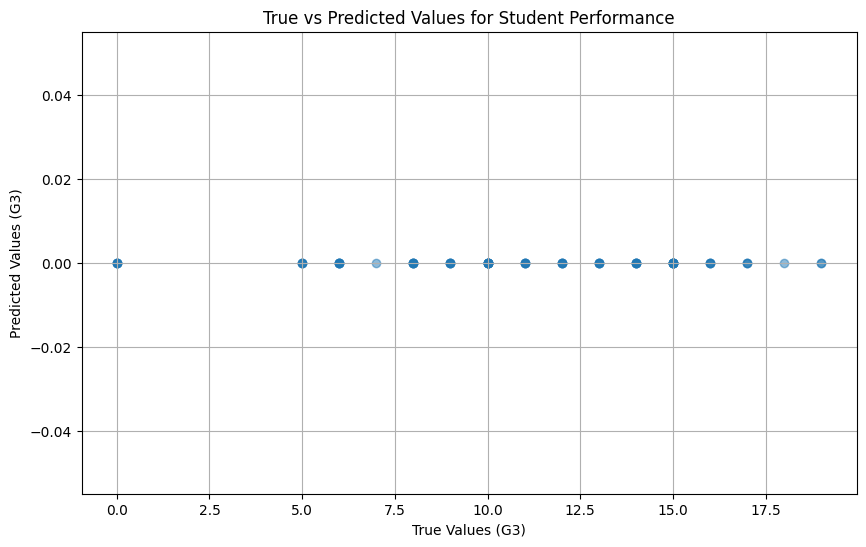

In [77]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, predicted_classes, alpha=0.5)
plt.xlabel('True Values (G3)')
plt.ylabel('Predicted Values (G3)')
plt.title('True vs Predicted Values for Student Performance')
plt.grid()
plt.show()